In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

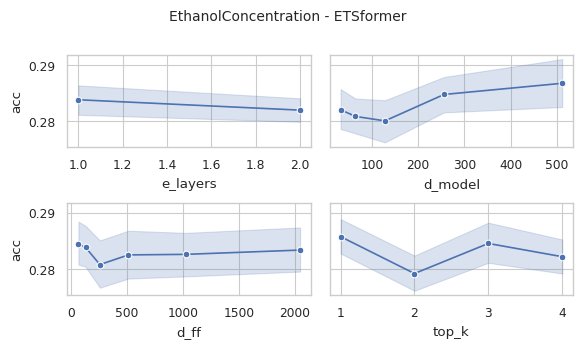

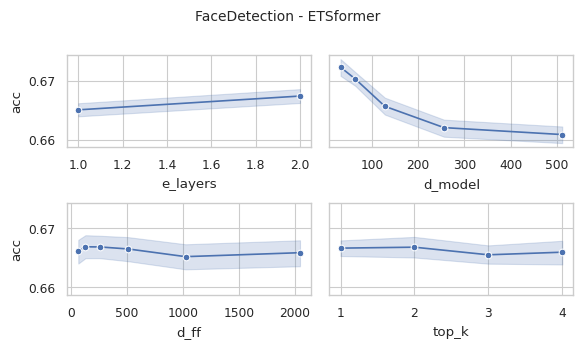

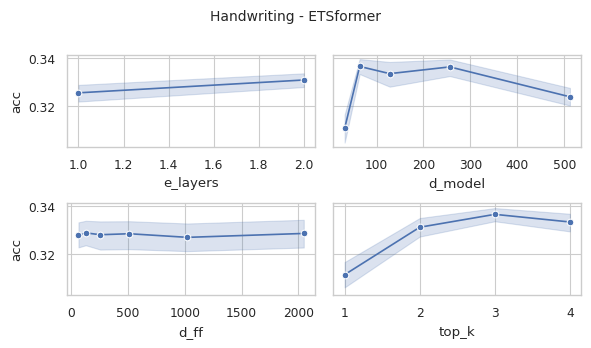

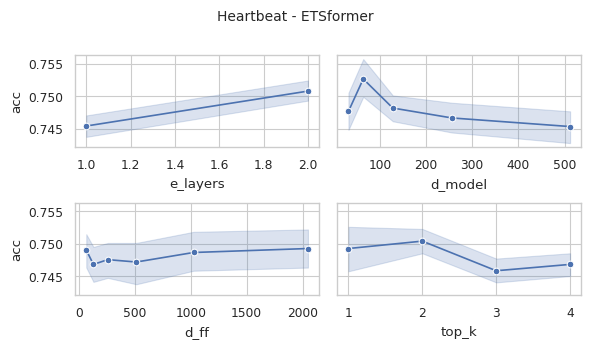

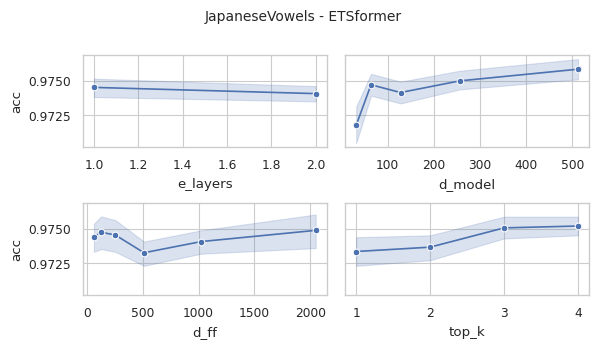

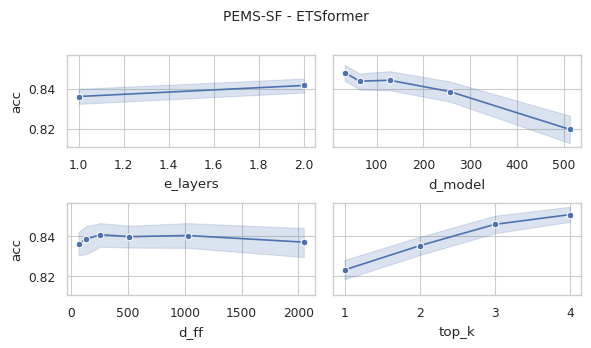

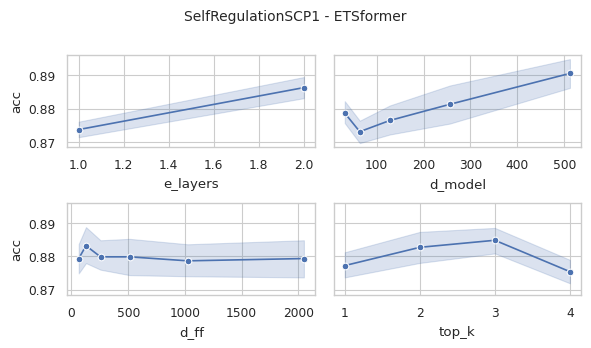

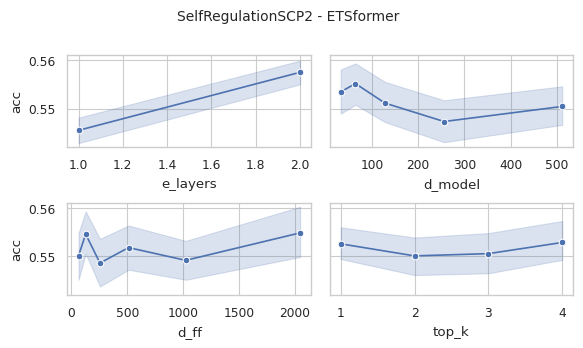

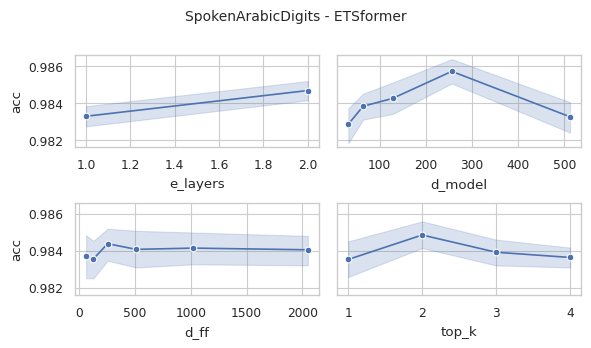

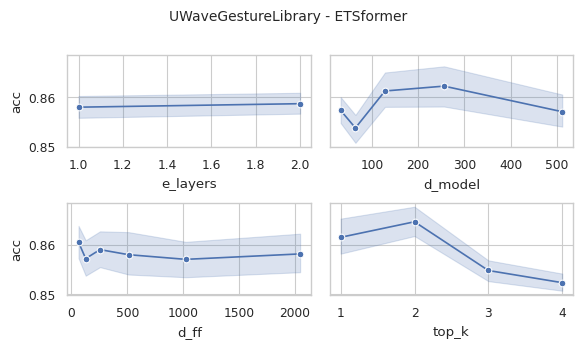

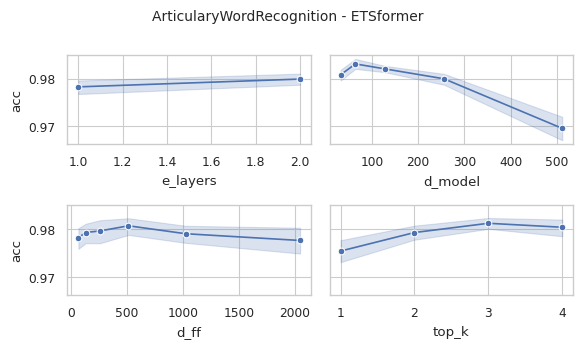

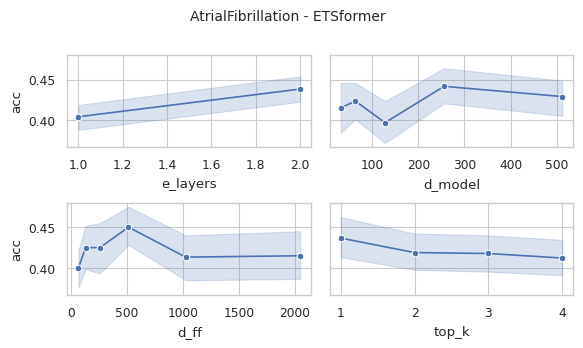

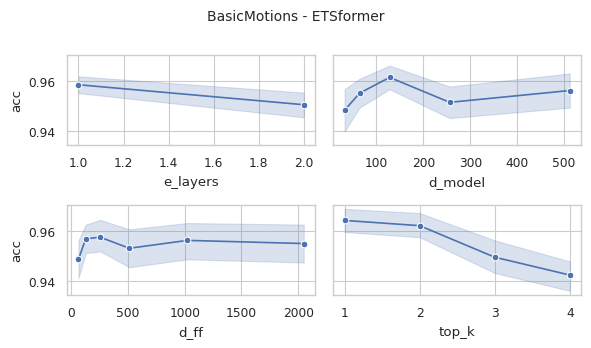

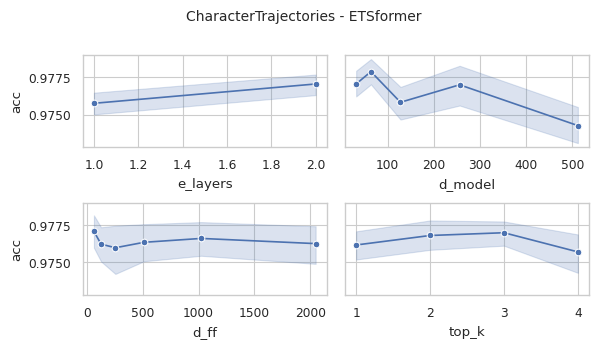

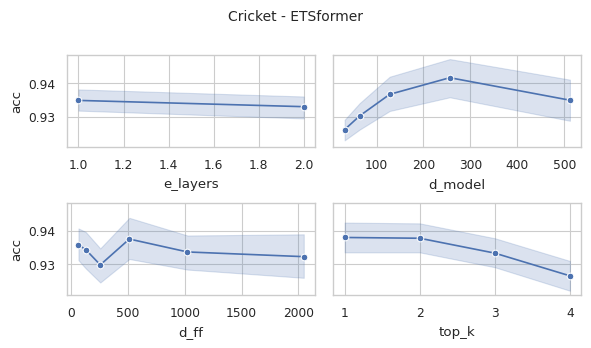

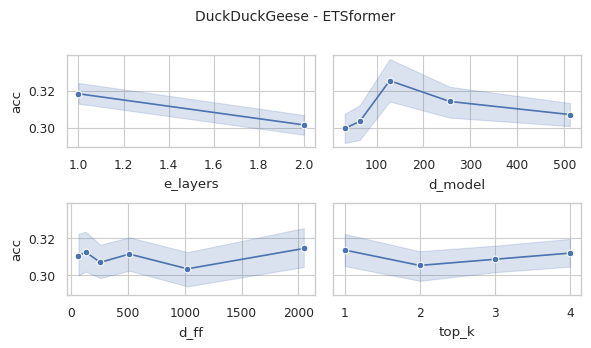

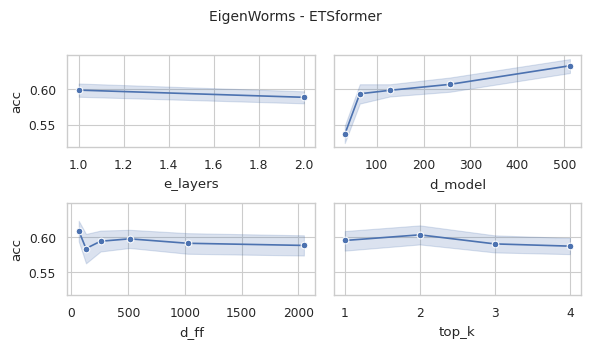

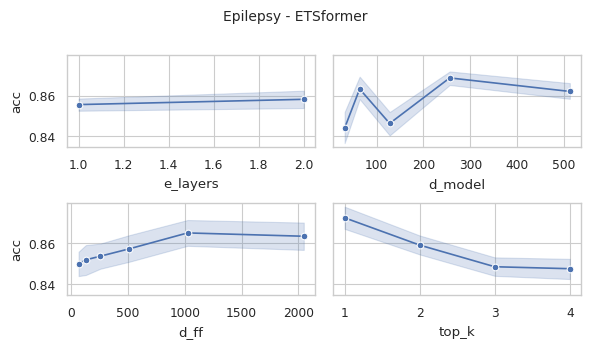

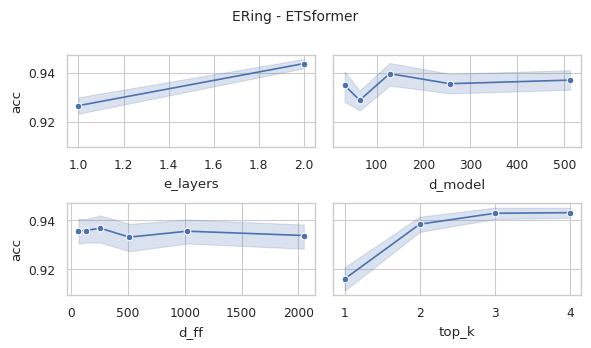

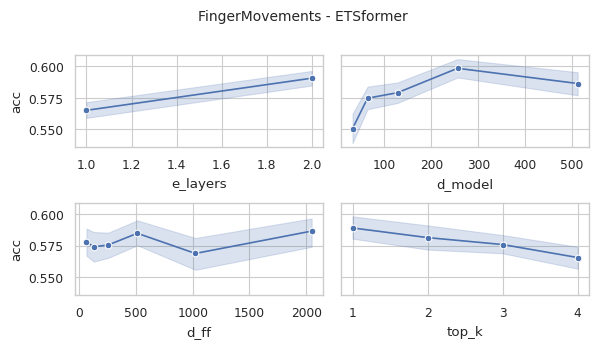

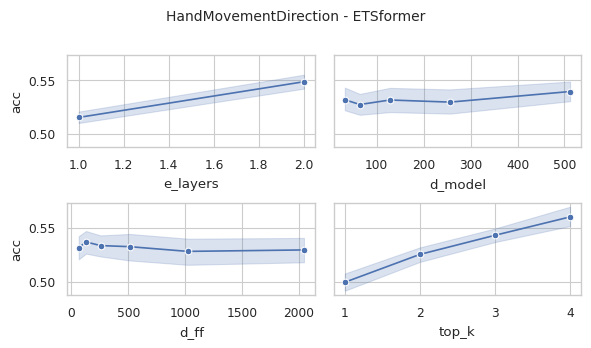

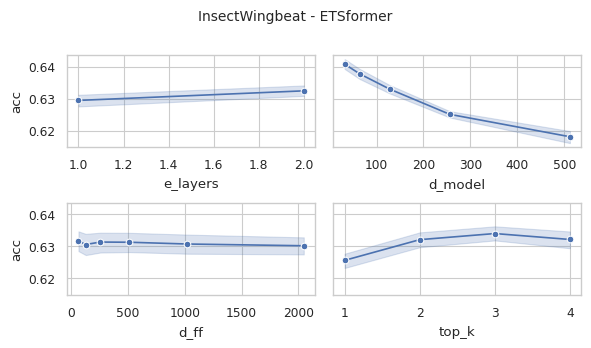

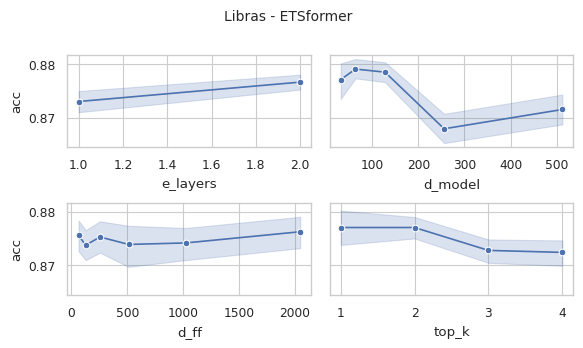

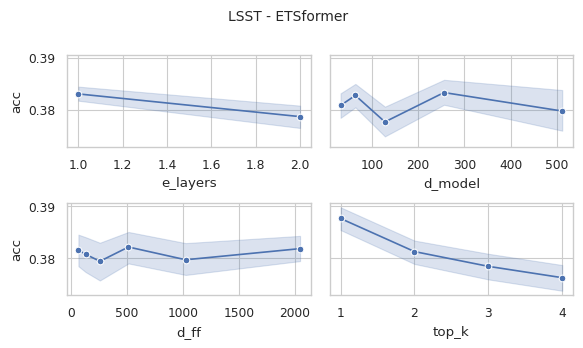

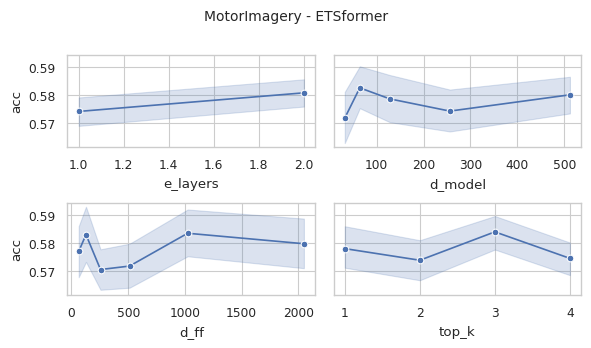

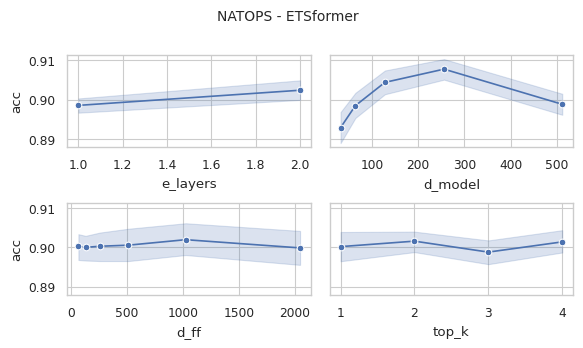

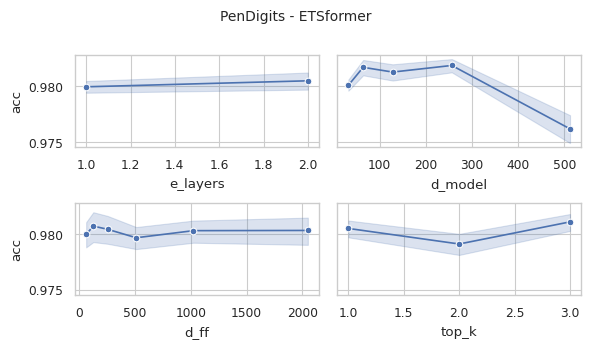

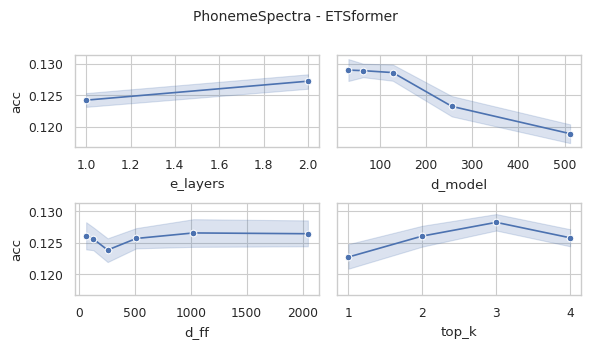

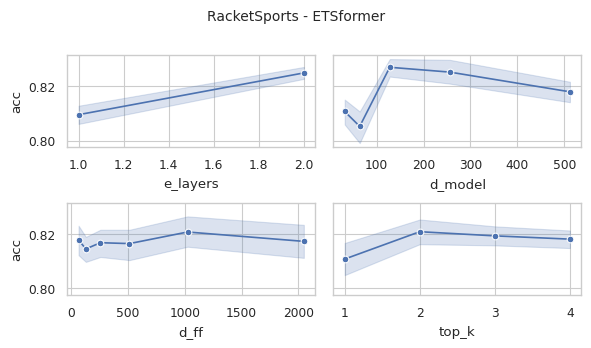

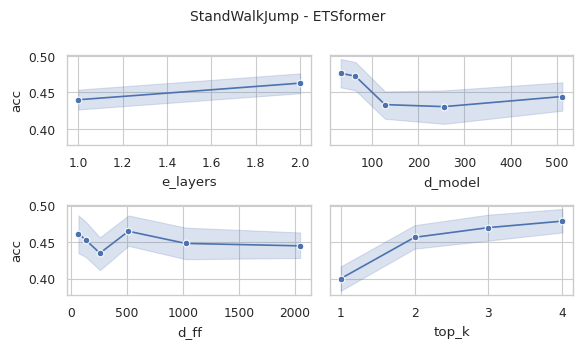

In [4]:
model = 'ETSformer'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('dm', ''))
            data_meta[10] = int(data_meta[10].replace('nh', ''))
            data_meta[11] = int(data_meta[11].replace('el', ''))
            data_meta[12] = int(data_meta[12].replace('dl', ''))
            data_meta[13] = int(data_meta[13].replace('df', ''))
            data_meta[14] = int(data_meta[14].replace('tk', ''))
            # data_meta[15] = data_meta[15].replace('exp', '')
            # data_meta[16] = data_meta[16].replace('desc', '')

            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'task_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'd_model': data_meta[9],
                'n_heads': data_meta[10],
                'e_layers': data_meta[11],
                'd_layers': data_meta[12],
                'd_ff': data_meta[13],
                'top_k': data_meta[14],
                # 'exp': data_meta[15],
                # 'desc': data_meta[16],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['e_layers', 'd_model', 'd_ff', 'top_k']
    num_cols, num_rows = 2, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    for i, col in enumerate(cols):
        sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='model', markers=True)
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    

In [5]:
model_configs = {
    "e_layers" : [1,2],
    "n_heads" : [8],
    "d_model" : [32,64,128,256,512],
    "d_ff" : [64,128,256,512,1024,2048],
    "top_k" : [1,2,3,4],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        # seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        # enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        e_layers = hyperparameter_combination['e_layers']
        d_model = hyperparameter_combination['d_model']
        n_heads = hyperparameter_combination['n_heads']
        d_ff = hyperparameter_combination['d_ff']
        top_k = hyperparameter_combination['top_k']

        # Since PenDigits only has seq_len=8, top_k=4 got error in execution
        # In this case, we will use top_k=3 accuracy instead since it makes more sense than using other values
        if data_name == 'PenDigits' and top_k == 4:
            top_k = 3
        
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['e_layers'] == e_layers)
                & (tmp['d_model'] == d_model)
                & (tmp['n_heads'] == n_heads)
                & (tmp['d_ff'] == d_ff)
                & (tmp['top_k'] == top_k)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



In [6]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'e_layers': 2, 'n_heads': 8, 'd_model': 256, 'd_ff': 64, 'top_k': 2}","{'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 128, 'top_k': 3}","{'e_layers': 2, 'n_heads': 8, 'd_model': 256, 'd_ff': 128, 'top_k': 2}","{'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 64, 'top_k': 2}","{'e_layers': 2, 'n_heads': 8, 'd_model': 256, 'd_ff': 256, 'top_k': 4}","{'e_layers': 2, 'n_heads': 8, 'd_model': 256, 'd_ff': 256, 'top_k': 3}","{'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 1024, 'top_k': 2}","{'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 1024, 'top_k': 3}","{'e_layers': 2, 'n_heads': 8, 'd_model': 256, 'd_ff': 128, 'top_k': 4}",...,"{'e_layers': 1, 'n_heads': 8, 'd_model': 128, 'd_ff': 128, 'top_k': 1}","{'e_layers': 1, 'n_heads': 8, 'd_model': 128, 'd_ff': 1024, 'top_k': 4}","{'e_layers': 1, 'n_heads': 8, 'd_model': 64, 'd_ff': 128, 'top_k': 1}","{'e_layers': 1, 'n_heads': 8, 'd_model': 32, 'd_ff': 2048, 'top_k': 2}","{'e_layers': 1, 'n_heads': 8, 'd_model': 32, 'd_ff': 2048, 'top_k': 1}","{'e_layers': 1, 'n_heads': 8, 'd_model': 64, 'd_ff': 1024, 'top_k': 1}","{'e_layers': 1, 'n_heads': 8, 'd_model': 32, 'd_ff': 128, 'top_k': 1}","{'e_layers': 1, 'n_heads': 8, 'd_model': 32, 'd_ff': 256, 'top_k': 1}","{'e_layers': 1, 'n_heads': 8, 'd_model': 32, 'd_ff': 1024, 'top_k': 2}","{'e_layers': 1, 'n_heads': 8, 'd_model': 32, 'd_ff': 1024, 'top_k': 1}"
EthanolConcentration,0.330798,0.281369,0.273764,0.269962,0.292776,0.262357,0.292776,0.273764,0.30038,0.269962,...,0.273764,0.26616,0.292776,0.262357,0.277567,0.269962,0.281369,0.285171,0.269962,0.307985
FaceDetection,0.683314,0.666005,0.669694,0.659194,0.671112,0.666856,0.662599,0.671396,0.668558,0.663167,...,0.660329,0.659762,0.670545,0.673666,0.671396,0.673099,0.663167,0.670829,0.676788,0.669977
Handwriting,0.356471,0.337647,0.342353,0.336471,0.338824,0.350588,0.337647,0.334118,0.335294,0.332941,...,0.298824,0.338824,0.314118,0.305882,0.270588,0.310588,0.272941,0.269412,0.297647,0.268235
Heartbeat,0.785366,0.756098,0.746341,0.741463,0.741463,0.75122,0.756098,0.765854,0.75122,0.75122,...,0.75122,0.741463,0.75122,0.765854,0.741463,0.746341,0.726829,0.731707,0.760976,0.736585
JapaneseVowels,0.983784,0.975676,0.972973,0.975676,0.975676,0.972973,0.97027,0.972973,0.972973,0.975676,...,0.975676,0.975676,0.975676,0.964865,0.967568,0.972973,0.967568,0.962162,0.97027,0.964865
PEMS-SF,0.878613,0.83237,0.843931,0.83815,0.861272,0.855491,0.878613,0.83237,0.843931,0.855491,...,0.815029,0.83815,0.83815,0.83815,0.861272,0.83237,0.83237,0.82659,0.843931,0.849711
SelfRegulationSCP1,0.921502,0.904437,0.866894,0.911263,0.887372,0.901024,0.904437,0.880546,0.897611,0.890785,...,0.87372,0.880546,0.887372,0.880546,0.877133,0.856655,0.856655,0.877133,0.880546,0.880546
SelfRegulationSCP2,0.6,0.555556,0.588889,0.577778,0.583333,0.572222,0.55,0.566667,0.555556,0.566667,...,0.561111,0.516667,0.555556,0.55,0.555556,0.55,0.544444,0.555556,0.544444,0.555556
SpokenArabicDigits,0.989995,0.988631,0.983174,0.986812,0.987267,0.988176,0.985448,0.987267,0.983629,0.986812,...,0.980446,0.981355,0.9809,0.980446,0.982265,0.988631,0.974534,0.979991,0.98181,0.975443
UWaveGestureLibrary,0.896875,0.86875,0.8375,0.878125,0.859375,0.85,0.846875,0.846875,0.85,0.8625,...,0.840625,0.853125,0.85625,0.8625,0.84375,0.846875,0.846875,0.85,0.875,0.84375


In [7]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'e_layers': 2, 'n_heads': 8, 'd_model': 256, 'd_ff': 64, 'top_k': 2}"
EthanolConcentration,33.07984790874524,28.13688212927757
FaceDetection,68.33144154370035,66.60045402951191
Handwriting,35.64705882352941,33.76470588235294
Heartbeat,78.53658536585367,75.60975609756098
JapaneseVowels,98.37837837837839,97.56756756756756
PEMS-SF,87.86127167630057,83.23699421965318
SelfRegulationSCP1,92.15017064846417,90.44368600682594
SelfRegulationSCP2,60.0,55.55555555555556
SpokenArabicDigits,98.99954524783993,98.86311959981809
UWaveGestureLibrary,89.6875,86.875
